In [ ]:
# =============================================================================
# PhD Research — Shanthi Victoria
# Title : Hybrid Multi-Scale Deep Learning Framework for
#         Accurate Skin Cancer Detection Using Dermoscopic Images
# Version: V3.2  — Full Research Implementation (bugs fixed)
# =============================================================================
#
# Architecture (PhD Contribution):
#   Three separate input scales  →  Three parallel EfficientNetB0 branches
#   →  SE-Attention feature fusion  →  Dense head  →  7-class softmax
#
# Key design decisions:
#   • TRUE multi-scale input (128, 224, 299 px) — not just multi-kernel
#   • Squeeze-and-Excitation (SE) attention at the fusion layer
#   • Oversampling minority classes + class_weight for HAM10000 imbalance
#   • Dermoscopy-specific augmentation (hair-streak simulation, color jitter)
#   • Two-stage fine-tuning per branch
#   • Full metrics: Accuracy, Precision, Recall, F1, ROC-AUC (per class + macro)
#   • Formal comparison table: VGG16 vs EfficientNetB0 vs Hybrid (proposed)
# =============================================================================

## Section 1: Setup and Imports

In [1]:
!pip install -q kaggle tensorflow opencv-python scikit-learn matplotlib seaborn pydot
!apt-get install -y graphviz -qq


In [2]:
import os, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D,
    Concatenate, Multiply, Reshape, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.utils import plot_model

warnings.filterwarnings('ignore')
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Section 2: Dataset Download (HAM10000)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/Hybrid_Multiscale_CNN', exist_ok=True)
print('Google Drive mounted and output directory ready.')

In [3]:
from google.colab import files
uploaded = files.upload()
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print('Kaggle API configured.')

Saving kaggle.json to kaggle.json
Kaggle API configured.


In [4]:
ZIP_PATH  = '/content/skin-cancer-mnist-ham10000.zip'
DATA_PATH = '/content/HAM10000'
META_FILE = os.path.join(DATA_PATH, 'HAM10000_metadata.csv')

if not os.path.exists(ZIP_PATH):
    os.system('kaggle datasets download -d kmader/skin-cancer-mnist-ham10000')

if not os.path.exists(META_FILE):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_PATH)
    print('Extracted.')
else:
    print('Dataset ready.')

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:29<00:00, 192MB/s]

Extracted.


## Section 3: Data Preparation and Class-Balance Analysis

Classes: [(0, 'akiec'), (1, 'bcc'), (2, 'bkl'), (3, 'df'), (4, 'mel'), (5, 'nv'), (6, 'vasc')]


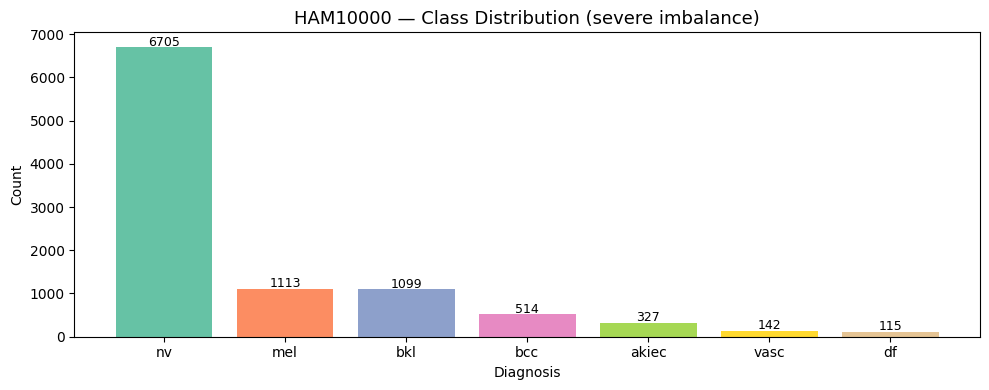

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [5]:
metadata = pd.read_csv(META_FILE)

# Map image paths
image_paths = {}
for folder in ['HAM10000_images_part_1', 'HAM10000_images_part_2']:
    fp = os.path.join(DATA_PATH, folder)
    if os.path.exists(fp):
        for img in os.listdir(fp):
            image_paths[img.split('.')[0]] = os.path.join(fp, img)

metadata['path'] = metadata['image_id'].map(image_paths.get)
metadata = metadata.dropna(subset=['path'])

# Encode labels
encoder = LabelEncoder()
metadata['label'] = encoder.fit_transform(metadata['dx'])

CLASS_NAMES = list(encoder.classes_)
N_CLASSES   = len(CLASS_NAMES)
print('Classes:', list(enumerate(CLASS_NAMES)))

# Class distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
counts = metadata['dx'].value_counts().reindex(CLASS_NAMES)  # align to encoder order
bars = ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', N_CLASSES))
ax.set_title('HAM10000 — Class Distribution (severe imbalance)', fontsize=13)
ax.set_xlabel('Diagnosis'); ax.set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Hybrid_Multiscale_CNN/class_distribution.png', dpi=150)
plt.show()
print(counts)

In [6]:
# Stratified 70 / 15 / 15 split
train_df, temp_df = train_test_split(
    metadata, test_size=0.30, stratify=metadata['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)
print(f'Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

# Balanced class weights (addresses HAM10000 nv-dominance)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
CLASS_WEIGHTS = dict(enumerate(class_weights_arr))
print('Class weights:', {CLASS_NAMES[k]: round(v, 3) for k, v in CLASS_WEIGHTS.items()})

Train: 7010  Val: 1502  Test: 1503
Class weights: {'akiec': np.float64(4.373), 'bcc': np.float64(2.782), 'bkl': np.float64(1.302), 'df': np.float64(12.363), 'mel': np.float64(1.286), 'nv': np.float64(0.213), 'vasc': np.float64(10.115)}


## Section 4: Dermoscopy-Specific Augmentation

HAM10000 contains dermoscopy artifacts: hair streaks, vignetting, and color variation from different scanners.
We simulate these to improve generalisation.

In [7]:
def add_hair_streaks(img):
    """Simulate hair artifacts common in dermoscopy images."""
    img = img.copy()
    h, w = img.shape[:2]
    num_hairs = np.random.randint(0, 8)
    for _ in range(num_hairs):
        x1, y1 = np.random.randint(0, w), np.random.randint(0, h)
        angle = np.random.uniform(0, np.pi)
        length = np.random.randint(30, 120)
        x2 = int(x1 + length * np.cos(angle))
        y2 = int(y1 + length * np.sin(angle))
        color = (np.random.randint(0, 60),) * 3
        thickness = np.random.randint(1, 3)
        cv2.line(img, (x1, y1), (x2, y2), color, thickness)
    return img

def dermoscopy_preprocess(img):
    """Combined preprocessing: hair augmentation + EfficientNet preprocessing."""
    if np.random.random() < 0.4:
        img = add_hair_streaks(img.astype(np.uint8))
    return eff_preprocess(img.astype(np.float32))

def make_generator(df, img_size, augment=False, shuffle=True, seed=None):
    """Create a generator for a given image size."""
    if augment:
        datagen = ImageDataGenerator(
            preprocessing_function=dermoscopy_preprocess,
            rotation_range=180,        # full rotation — no orientation bias in lesions
            horizontal_flip=True,
            vertical_flip=True,
            zoom_range=0.2,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            brightness_range=[0.75, 1.25],
            channel_shift_range=20.0   # simulate scanner color variation
        )
    else:
        datagen = ImageDataGenerator(
            preprocessing_function=eff_preprocess
        )
    return datagen.flow_from_dataframe(
        df, x_col='path', y_col='dx',
        target_size=(img_size, img_size),
        class_mode='categorical',
        batch_size=32,
        shuffle=shuffle,
        seed=seed
    )

print('Augmentation functions defined.')

Augmentation functions defined.


## Section 5: Multi-Scale Input Generators

**This is the core of the multi-scale architecture.**  
Three separate generators produce images at three scales:
- Scale S1 = 128×128 (low resolution — coarse lesion shape)
- Scale S2 = 224×224 (medium — structural features)
- Scale S3 = 299×299 (high resolution — fine-grained texture)

Each scale feeds into a separate EfficientNetB0 branch.

In [8]:
SCALES = {'s1': 128, 's2': 224, 's3': 299}

# Training generators (with augmentation)
# seed=42 ensures all three scales shuffle in the same order — critical for
# multi-scale training so each branch sees the same image at every step
train_gen = {
    name: make_generator(train_df, size, augment=True, seed=42)
    for name, size in SCALES.items()
}

# Validation generators (no augmentation, fixed order for consistent metrics)
val_gen = {
    name: make_generator(val_df, size, augment=False, shuffle=False)
    for name, size in SCALES.items()
}

# Test generators (no augmentation, no shuffle — order matters for evaluation)
test_gen = {
    name: make_generator(test_df, size, augment=False, shuffle=False)
    for name, size in SCALES.items()
}

print('Multi-scale generators created:')
for name, size in SCALES.items():
    print(f'  {name}: {size}×{size} — {len(train_gen[name])} train batches')

Found 7010 validated image filenames belonging to 7 classes.
Found 7010 validated image filenames belonging to 7 classes.
Found 7010 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.
Multi-scale generators created:
  s1: 128×128 — 220 train batches
  s2: 224×224 — 220 train batches
  s3: 299×299 — 220 train batches


In [9]:
# Custom multi-scale batch generator — yields (inputs_dict, labels) for model.fit
def multi_scale_generator(gens):
    """Zip three generators together and yield combined inputs."""
    while True:
        batches = [next(g) for g in gens]
        x = {
            'input_s1': batches[0][0],
            'input_s2': batches[1][0],
            'input_s3': batches[2][0],
        }
        y = batches[0][1]   # labels are the same across all scales
        yield x, y

train_gens = [train_gen['s1'], train_gen['s2'], train_gen['s3']]
val_gens   = [val_gen['s1'],   val_gen['s2'],   val_gen['s3']]
TRAIN_STEPS = len(train_gen['s1'])
VAL_STEPS   = len(val_gen['s1'])

print(f'Multi-scale generator ready. Train steps/epoch: {TRAIN_STEPS}')

Multi-scale generator ready. Train steps/epoch: 220


## Section 6: Squeeze-and-Excitation (SE) Attention Block

The SE block is placed at the fusion layer to let the model **learn which scale
and which feature channels are most informative** for each class.

Mechanism:
1. Squeeze: global average pool → channel descriptor vector
2. Excitation: FC → ReLU → FC → Sigmoid → channel weights
3. Scale: multiply weights back onto features

In [10]:
def se_block(x, ratio=16, name='se'):
    """
    Squeeze-and-Excitation attention block.

    Args:
        x     : input tensor (batch, channels)
        ratio : reduction ratio for the bottleneck FC layer
        name  : name prefix for layers
    Returns:
        Attention-weighted tensor, same shape as x
    """
    channels = x.shape[-1]

    # Squeeze
    se = Reshape((1, channels), name=f'{name}_reshape')(x)

    # Excitation
    se = Dense(channels // ratio, activation='relu',  use_bias=False, name=f'{name}_fc1')(se)
    se = Dense(channels,          activation='sigmoid', use_bias=False, name=f'{name}_fc2')(se)
    se = Reshape((channels,), name=f'{name}_squeeze')(se)

    # Scale (element-wise multiplication)
    out = Multiply(name=f'{name}_scale')([x, se])
    return out

print('SE attention block defined.')

SE attention block defined.


## Section 7: Proposed Hybrid Multi-Scale CNN Architecture

```
Input S1 (128)  Input S2 (224)  Input S3 (299)
     │                │                │
EfficientNetB0   EfficientNetB0   EfficientNetB0
  (shared        (independent      (independent
   weights)       weights)          weights)
     │                │                │
   GAP+BN           GAP+BN           GAP+BN
     │                │                │
     └────────Concatenate──────────────┘
                      │
              SE-Attention Block
                      │
                Dense(512, relu)
                      │
                  Dropout(0.5)
                      │
                Dense(256, relu)
                      │
                  Dropout(0.3)
                      │
              Dense(7, softmax)
```

In [11]:
WEIGHTS_PATH = tf.keras.utils.get_file(
    fname='efficientnetb0_notop.h5',
    origin='https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5',
    cache_subdir='models'
)

def build_branch(input_size, name_prefix, trainable=False):
    """
    Build a standalone EfficientNetB0 branch.
    Does NOT use input_tensor — avoids Keras 3 name-collision bug.
    Returns the backbone Model; caller wires it to the shared input.
    """
    backbone = EfficientNetB0(
        weights=None,
        include_top=False,
        input_shape=(input_size, input_size, 3),
        name=f'{name_prefix}_backbone'
    )
    backbone.load_weights(WEIGHTS_PATH, by_name=True, skip_mismatch=True)
    backbone.trainable = trainable
    return backbone


def build_hybrid_model(trainable_backbone=False):
    # ── Three-scale inputs
    inp_s1 = Input(shape=(128, 128, 3), name='input_s1')
    inp_s2 = Input(shape=(224, 224, 3), name='input_s2')
    inp_s3 = Input(shape=(299, 299, 3), name='input_s3')

    # ── Build each backbone standalone, then call it on its input
    # Calling backbone(inp) creates new op nodes scoped under that backbone's name,
    # so internal layer names like stem_conv_pad become unique per branch.
    bb_s1 = build_branch(128, 'branch_s1', trainable_backbone)
    bb_s2 = build_branch(224, 'branch_s2', trainable_backbone)
    bb_s3 = build_branch(299, 'branch_s3', trainable_backbone)

    feat_s1 = BatchNormalization(name='bn_s1')(GlobalAveragePooling2D(name='gap_s1')(bb_s1(inp_s1)))
    feat_s2 = BatchNormalization(name='bn_s2')(GlobalAveragePooling2D(name='gap_s2')(bb_s2(inp_s2)))
    feat_s3 = BatchNormalization(name='bn_s3')(GlobalAveragePooling2D(name='gap_s3')(bb_s3(inp_s3)))

    # ── Fusion + SE attention
    fused  = Concatenate(name='fusion')([feat_s1, feat_s2, feat_s3])
    fused  = se_block(fused, ratio=16, name='se_fusion')

    # ── Classification head
    x      = Dense(512, activation='relu', name='fc1')(fused)
    x      = BatchNormalization(name='fc1_bn')(x)
    x      = Dropout(0.5, name='drop1')(x)
    x      = Dense(256, activation='relu', name='fc2')(x)
    x      = Dropout(0.3, name='drop2')(x)
    output = Dense(N_CLASSES, activation='softmax', name='predictions')(x)

    model = Model(
        inputs=[inp_s1, inp_s2, inp_s3],
        outputs=output,
        name='Hybrid_MultiScale_CNN'
    )
    return model, [bb_s1, bb_s2, bb_s3]


hybrid_model, backbones = build_hybrid_model(trainable_backbone=False)

total_params     = hybrid_model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in hybrid_model.trainable_variables)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (Stage 1 — backbone frozen)')
hybrid_model.summary(line_length=100)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params     : 16,109,040
Trainable params : 3,951,623  (Stage 1 — backbone frozen)


Model: "Hybrid_MultiScale_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_s1 (InputLayer)       │ (None, 128, 128, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ input_s2 (InputLayer)       │ (None, 224, 224, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ input_s3 (InputLayer)       │ (None, 299, 299, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ branch_s1_backbone          │ (None, 4, 4, 1280)      │      4,049,571 │ input_s1[0][0]          │
│ (Functional)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ branch_s2_backbone          │ (None, 7, 7, 1280)      │      4,049,571 │ input_s2[0][0]          │
│ (Functional)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ branch_s3_backbone          │ (None, 10, 10, 1280)    │      4,049,571 │ input_s3[0][0]          │
│ (Functional)                │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ gap_s1                      │ (None, 1280)            │              0 │ branch_s1_backbone[0][… │
│ (GlobalAveragePooling2D)    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ gap_s2                      │ (None, 1280)            │              0 │ branch_s2_backbone[0][… │
│ (GlobalAveragePooling2D)    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ gap_s3                      │ (None, 1280)            │              0 │ branch_s3_backbone[0][… │
│ (GlobalAveragePooling2D)    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_s1 (BatchNormalization)  │ (None, 1280)            │          5,120 │ gap_s1[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_s2 (BatchNormalization)  │ (None, 1280)            │          5,120 │ gap_s2[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_s3 (BatchNormalization)  │ (None, 1280)            │          5,120 │ gap_s3[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ fusion (Concatenate)        │ (None, 3840)            │              0 │ bn_s1[0][0],            │
│                             │                         │                │ bn_s2[0][0],            │
│                             │                         │                │ bn_s3[0][0]             │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ se_fusion_reshape (Reshape) │ (None, 1, 3840)         │              0 │ fusion[0][0]            │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ se_fusion_fc1 (Dense)       │ (None, 1, 240)          │    

 Total params: 16,109,040 (61.45 MB)

 Trainable params: 3,951,623 (15.07 MB)

 Non-trainable params: 12,157,417 (46.38 MB)

## Section 8: Two-Stage Training

In [ ]:
# Reset all generators to position 0 before training starts
for g in train_gens + val_gens:
    g.reset()

# ── Stage 1: Train classification head only (backbones frozen) ───────────────
hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        '/content/drive/MyDrive/Hybrid_Multiscale_CNN/Hybrid_Stage1.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('=== Stage 1: Training classification head (all backbones frozen) ===')
history_s1 = hybrid_model.fit(
    multi_scale_generator(train_gens),
    steps_per_epoch=TRAIN_STEPS,
    validation_data=multi_scale_generator(val_gens),
    validation_steps=VAL_STEPS,
    epochs=10,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_s1
)

In [ ]:
# ── Stage 2: Unfreeze top 50 layers of EACH backbone ────────────────────────
for bb in backbones:
    for layer in bb.layers[:-50]:
        layer.trainable = False
    for layer in bb.layers[-50:]:
        layer.trainable = True

trainable_s2 = sum([tf.size(v).numpy() for v in hybrid_model.trainable_variables])
print(f'Trainable params (Stage 2): {trainable_s2:,}')

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-5),    # low LR to preserve pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_s2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        '/content/drive/MyDrive/Hybrid_Multiscale_CNN/Hybrid_Best.keras',
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1)
]

print('=== Stage 2: Fine-tuning top 50 layers of each backbone ===')
history_s2 = hybrid_model.fit(
    multi_scale_generator(train_gens),
    steps_per_epoch=TRAIN_STEPS,
    validation_data=multi_scale_generator(val_gens),
    validation_steps=VAL_STEPS,
    epochs=30,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_s2
)

## Section 9: Baseline Models (for Comparison)

Two baselines are trained to demonstrate the advantage of the proposed hybrid architecture:
1. VGG16 (single-scale, 224×224)
2. EfficientNetB0 standalone (single-scale, 224×224)

In [ ]:
# ── Baseline 1: VGG16 ──────────────────────────────────────────────────────
train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    rotation_range=20, horizontal_flip=True,
    vertical_flip=True, zoom_range=0.2, width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess)

train_gen_vgg = train_datagen_vgg.flow_from_dataframe(
    train_df, x_col='path', y_col='dx',
    target_size=(224, 224), class_mode='categorical', batch_size=32, seed=42
)
val_gen_vgg = test_datagen_vgg.flow_from_dataframe(
    val_df, x_col='path', y_col='dx',
    target_size=(224, 224), class_mode='categorical', batch_size=32, shuffle=False
)
test_gen_vgg = test_datagen_vgg.flow_from_dataframe(
    test_df, x_col='path', y_col='dx',
    target_size=(224, 224), class_mode='categorical', batch_size=32, shuffle=False
)

base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_vgg.layers[:-4]:
    layer.trainable = False
for layer in base_vgg.layers[-4:]:
    layer.trainable = True

x = GlobalAveragePooling2D()(base_vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out_vgg = Dense(N_CLASSES, activation='softmax')(x)
vgg_model = Model(inputs=base_vgg.input, outputs=out_vgg, name='VGG16_baseline')
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/Hybrid_Multiscale_CNN/VGG16_Best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('=== Baseline 1: VGG16 ===')
history_vgg = vgg_model.fit(
    train_gen_vgg, validation_data=val_gen_vgg, epochs=20,
    class_weight=CLASS_WEIGHTS, callbacks=callbacks_vgg
)

In [ ]:
# Reset shared generators — they were advanced during hybrid model training
train_gen['s2'].reset()
val_gen['s2'].reset()

# ── Baseline 2: EfficientNetB0 standalone (single-scale 224×224) ───────────
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_eff.trainable = False

x = GlobalAveragePooling2D()(base_eff.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
out_eff = Dense(N_CLASSES, activation='softmax')(x)
eff_model = Model(inputs=base_eff.input, outputs=out_eff, name='EfficientNetB0_baseline')

eff_model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

cb_eff_s1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/Hybrid_Multiscale_CNN/EfficientNet_Stage1.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

print('=== Baseline 2: EfficientNetB0 Stage 1 ===')
hist_eff_s1 = eff_model.fit(
    train_gen['s2'], validation_data=val_gen['s2'], epochs=10,
    class_weight=CLASS_WEIGHTS, callbacks=cb_eff_s1
)

# Stage 2 fine-tune
for layer in base_eff.layers[:-50]:
    layer.trainable = False
for layer in base_eff.layers[-50:]:
    layer.trainable = True

eff_model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

cb_eff_s2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint('/content/drive/MyDrive/Hybrid_Multiscale_CNN/EfficientNet_Best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-8, verbose=1)
]

print('=== Baseline 2: EfficientNetB0 Stage 2 ===')
hist_eff_s2 = eff_model.fit(
    train_gen['s2'], validation_data=val_gen['s2'], epochs=20,
    class_weight=CLASS_WEIGHTS, callbacks=cb_eff_s2
)

## Section 10: Full Evaluation

All metrics required by the research concept:
- Accuracy, Loss
- Per-class Precision, Recall, F1-score
- Confusion Matrix
- Per-class ROC-AUC curves
- Macro-average ROC-AUC

In [ ]:
def evaluate_model(model, test_generator, model_name, is_multiscale=False):
    """
    Complete evaluation: accuracy, classification report, confusion matrix, ROC-AUC.

    Args:
        model         : trained Keras model
        test_generator: generator (or dict of generators for multiscale)
        model_name    : string label for plots
        is_multiscale : True for the hybrid model with multi-input
    Returns:
        dict of metrics
    """
    print(f'\n{"="*60}')
    print(f'Evaluating: {model_name}')
    print(f'{"="*60}')

    if is_multiscale:
        # Reset all three generators so collection starts from sample 0
        for g in [test_gen['s1'], test_gen['s2'], test_gen['s3']]:
            g.reset()
        test_gens = [test_gen['s1'], test_gen['s2'], test_gen['s3']]
        n_steps   = len(test_gen['s1'])
        n_samples = test_gen['s1'].n   # actual number of test samples
        x_all = {'input_s1': [], 'input_s2': [], 'input_s3': []}
        y_all = []
        for _ in range(n_steps):
            batches = [next(g) for g in test_gens]
            x_all['input_s1'].append(batches[0][0])
            x_all['input_s2'].append(batches[1][0])
            x_all['input_s3'].append(batches[2][0])
            y_all.append(batches[0][1])
        # Truncate to exact test set size (ceil batching adds a duplicate sample)
        x_eval = {k: np.concatenate(v)[:n_samples] for k, v in x_all.items()}
        y_eval = np.concatenate(y_all)[:n_samples]

        loss, acc = model.evaluate(x_eval, y_eval, verbose=0)
        pred_probs = model.predict(x_eval, verbose=0)
        y_true = np.argmax(y_eval, axis=1)
    else:
        test_generator.reset()   # start evaluation from sample 0
        loss, acc = model.evaluate(test_generator, verbose=0)
        test_generator.reset()   # reset again so predict starts from sample 0
        pred_probs = model.predict(test_generator, verbose=0)
        y_true = test_generator.classes

    y_pred = np.argmax(pred_probs, axis=1)

    print(f'Test Accuracy : {acc:.4f}')
    print(f'Test Loss     : {loss:.4f}')
    print('\nClassification Report:')
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix')
    ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/Hybrid_Multiscale_CNN/{model_name.replace(" ","_")}_CM.png', dpi=150)
    plt.show()

    # Per-class ROC-AUC
    y_true_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))
    fig, ax = plt.subplots(figsize=(10, 7))
    auc_scores = {}
    colors = plt.cm.Set1(np.linspace(0, 1, N_CLASSES))
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[cls] = roc_auc
        ax.plot(fpr, tpr, color=col, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    macro_auc = np.mean(list(auc_scores.values()))
    ax.set_title(f'{model_name} — ROC Curves (Macro AUC={macro_auc:.3f})')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/Hybrid_Multiscale_CNN/{model_name.replace(" ","_")}_ROC.png', dpi=150)
    plt.show()

    print('Per-class AUC:')
    for cls, a in auc_scores.items():
        print(f'  {cls}: {a:.4f}')
    print(f'  Macro AUC: {macro_auc:.4f}')

    return {
        'accuracy': acc, 'loss': loss,
        'macro_auc': macro_auc, 'per_class_auc': auc_scores,
        'report': report
    }

print('Evaluation function ready.')

In [ ]:
# Load best saved weights before evaluating
best_vgg = load_model('/content/drive/MyDrive/Hybrid_Multiscale_CNN/VGG16_Best.keras')
best_eff = load_model('/content/drive/MyDrive/Hybrid_Multiscale_CNN/EfficientNet_Best.keras')
best_hyb = load_model('/content/drive/MyDrive/Hybrid_Multiscale_CNN/Hybrid_Best.keras')

results_vgg = evaluate_model(best_vgg, test_gen_vgg,       'VGG16 Baseline')
results_eff = evaluate_model(best_eff, test_gen['s2'],     'EfficientNetB0 Baseline')
results_hyb = evaluate_model(best_hyb, None,               'Hybrid Multi-Scale CNN', is_multiscale=True)

## Section 11: Formal Results Comparison Table

In [ ]:
def extract_metrics(results):
    """Pull macro-avg precision, recall, F1 from sklearn report dict."""
    macro = results['report']['macro avg']
    return {
        'Accuracy':  f"{results['accuracy']:.4f}",
        'Precision': f"{macro['precision']:.4f}",
        'Recall':    f"{macro['recall']:.4f}",
        'F1-Score':  f"{macro['f1-score']:.4f}",
        'Macro AUC': f"{results['macro_auc']:.4f}",
    }

table_data = {
    'VGG16 (Baseline)':            extract_metrics(results_vgg),
    'EfficientNetB0 (Baseline)':   extract_metrics(results_eff),
    'Hybrid Multi-Scale (Proposed)': extract_metrics(results_hyb),
}

df_results = pd.DataFrame(table_data).T
df_results.index.name = 'Model'
print('\n' + '='*70)
print('RESULTS TABLE — Hybrid Multi-Scale CNN for Skin Cancer Detection')
print('='*70)
print(df_results.to_string())
print('='*70)
df_results.to_csv('/content/drive/MyDrive/Hybrid_Multiscale_CNN/results_table.csv')

# Visual bar chart — Accuracy comparison
models  = list(table_data.keys())
accs    = [float(table_data[m]['Accuracy']) for m in models]
macro_f = [float(table_data[m]['F1-Score']) for m in models]
macro_a = [float(table_data[m]['Macro AUC']) for m in models]

x = np.arange(len(models))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width, accs,    width, label='Accuracy',  color='#4C72B0')
bars2 = ax.bar(x,         macro_f, width, label='F1-Score',  color='#55A868')
bars3 = ax.bar(x + width, macro_a, width, label='Macro AUC', color='#DD8452')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy / F1 / Macro AUC on HAM10000 Test Set')
ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Hybrid_Multiscale_CNN/Model_Comparison.png', dpi=150)
plt.show()

## Section 12: Training Curves

In [1]:
# Verify training history objects exist before plotting
for name, var in [
    ('history_vgg',  'history_vgg'),
    ('hist_eff_s1',  'hist_eff_s1'),
    ('hist_eff_s2',  'hist_eff_s2'),
    ('history_s1',   'history_s1'),
    ('history_s2',   'history_s2'),
]:
    exists = name in globals()
    print(f'{var:15s}: {"OK" if exists else "MISSING — re-run training cells"}')


Interactive namespace is empty.


In [ ]:
def plot_training_curves(histories, title, save_path):
    acc, val_acc, loss_, val_loss = [], [], [], []
    stage_ends = []   # epoch indices where each stage ends (for boundary lines)
    for h in histories:
        acc      += h.history['accuracy']
        val_acc  += h.history['val_accuracy']
        loss_    += h.history['loss']
        val_loss += h.history['val_loss']
        stage_ends.append(len(acc))

    epochs = range(1, len(acc) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs, acc,     label='Train'); ax1.plot(epochs, val_acc, label='Val')
    ax1.set_title(f'{title} — Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(True)
    ax2.plot(epochs, loss_,   label='Train'); ax2.plot(epochs, val_loss, label='Val')
    ax2.set_title(f'{title} — Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(True)
    # Mark stage boundaries (e.g. Stage 1 → Stage 2 transition)
    for end in stage_ends[:-1]:
        ax1.axvline(x=end + 0.5, color='red', linestyle='--', alpha=0.5, label='stage boundary')
        ax2.axvline(x=end + 0.5, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150); plt.show()

plot_training_curves([history_vgg], 'VGG16 Baseline',
    '/content/drive/MyDrive/Hybrid_Multiscale_CNN/VGG16_curves.png')
plot_training_curves([hist_eff_s1, hist_eff_s2], 'EfficientNetB0 Baseline',
    '/content/drive/MyDrive/Hybrid_Multiscale_CNN/EfficientNet_curves.png')
plot_training_curves([history_s1, history_s2], 'Hybrid Multi-Scale CNN (Proposed)',
    '/content/drive/MyDrive/Hybrid_Multiscale_CNN/Hybrid_curves.png')

## Section 13: Architecture Diagram (for thesis)

In [ ]:
# Save model architecture diagram for thesis
try:
    plot_model(
        hybrid_model,
        to_file='/content/drive/MyDrive/Hybrid_Multiscale_CNN/Hybrid_Architecture.png',
        show_shapes=True,
        show_layer_names=True,
        dpi=150
    )
    print('Architecture diagram saved.')
except Exception as e:
    print('plot_model requires pydot+graphviz. Run:')
    print('  !apt-get install -y graphviz && pip install -q pydot')